# 量子线路 → 门依赖图可视化

将量子线路转换为二分异构图中的**逻辑线路图**（Gate Dependency DAG），展示门节点间的依赖关系。

In [1]:
# 安装依赖（首次运行需取消注释）
# %pip install pylatexenc -q

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag

In [3]:
def build_gate_dag(qc):
    """从量子电路提取门依赖 DAG。
    
    返回 gate 列表，每个 gate 包含：
      index, name, qubits, is_two_qubit, is_measure, predecessors, depth, pos
    """
    dag = circuit_to_dag(qc)
    op_nodes = list(dag.topological_op_nodes())

    gates = []
    idx = 0
    for node in op_nodes:
        name = getattr(node.op, 'name', node.name)
        if name == 'barrier':
            continue
        qubits = [qc.find_bit(q).index for q in node.qargs]
        gates.append({
            'index': idx,
            'name': name,
            'qubits': qubits,
            'is_two_qubit': len(qubits) == 2,
            'is_measure': name == 'measure',
            'predecessors': [],
        })
        idx += 1

    last_on_q = {}
    for g in gates:
        for q in g['qubits']:
            if q in last_on_q:
                g['predecessors'].append(last_on_q[q])
            last_on_q[q] = g['index']

    depths = {}
    for g in gates:
        if not g['predecessors']:
            depths[g['index']] = 0
        else:
            depths[g['index']] = max(depths[p] for p in g['predecessors']) + 1
    for g in gates:
        g['depth'] = depths[g['index']]

    return gates

In [4]:
COLOR_MAP = {
    'h': '#5B9BD5',
    'cx': '#E74C3C',
    'cz': '#E67E22',
    'swap': '#E74C3C',
    'ecr': '#E74C3C',
    'x': '#9B59B6',
    'y': '#1ABC9C',
    'z': '#2ECC71',
    's': '#3498DB',
    't': '#2980B9',
    'rz': '#F39C12',
    'sx': '#E67E22',
    'measure': '#7F8C8D',
}
FALLBACK_COLOR = '#95A5A6'
GATE_LABELS = {
    'h': 'H', 'cx': 'CX', 'cz': 'CZ', 'swap': 'SWAP', 'ecr': 'ECR',
    'x': 'X', 'y': 'Y', 'z': 'Z', 's': 'S', 't': 'T',
    'rz': 'Rz', 'sx': 'SX', 'measure': 'M',
}

In [5]:
def draw_gate_dag(gates, num_qubits, figsize=(12, 5), title=None):
    """绘制门依赖 DAG——逻辑线路图。"""
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=150)
    fig.patch.set_facecolor('white')

    max_depth = max(g['depth'] for g in gates) if gates else 0

    # ---- layout parameters ----
    nw = 0.45            # node width
    nh_1q = 0.28         # node height (1q)
    nh_2q_base = 0.15    # node half-height above qubit (2q)
    arrow_color = '#AAAAAA'
    wire_color = '#D5D8DC'
    grid_color = '#F0F0F0'

    # ---- grid (subtle) ----
    for d in range(max_depth + 2):
        ax.axvline(d - 0.5, ymin=0, ymax=1, color=grid_color, linewidth=0.5, zorder=0)

    # ---- qubit wires ----
    for q in range(num_qubits):
        ax.axhline(y=q, xmin=0.02, xmax=0.98, color=wire_color, linewidth=2.5, zorder=1)
        ax.text(-0.55, q, f'$q_{{{q}}}$', fontsize=13, ha='center', va='center',
                color='#2C3E50', fontweight='bold')

    # ---- dependency arrows (behind nodes) ----
    for g in gates:
        for p_idx in g['predecessors']:
            pred = gates[p_idx]
            shared = set(pred['qubits']) & set(g['qubits'])
            if not shared:
                continue
            q = list(shared)[0]
            x_start = pred['depth'] + nw / 2
            x_end = g['depth'] - nw / 2
            dx = x_end - x_start
            if dx < 0.05:
                continue
            ax.annotate(
                '', xy=(x_end, q), xytext=(x_start, q),
                arrowprops=dict(
                    arrowstyle='->', color=arrow_color, lw=2.0,
                    connectionstyle='arc3,rad=0.15',
                ),
                zorder=2,
            )

    # ---- gate nodes ----
    for g in gates:
        x = g['depth']
        label = GATE_LABELS.get(g['name'], g['name'].upper())
        color = COLOR_MAP.get(g['name'], FALLBACK_COLOR)

        if g['is_two_qubit']:
            q0, q1 = min(g['qubits']), max(g['qubits'])
            h_total = (q1 - q0) + 2 * nh_2q_base
            rect = FancyBboxPatch(
                (x - nw / 2, q0 - nh_2q_base), nw, h_total,
                boxstyle='round,pad=0.04',
                facecolor=color, edgecolor='#444444',
                linewidth=1.8, alpha=0.90, zorder=3,
            )
            ax.add_patch(rect)
            ax.text(x, (q0 + q1) / 2, label, fontsize=11,
                    ha='center', va='center', color='white',
                    fontweight='bold', zorder=4)
        elif g['name'] == 'measure':
            q = g['qubits'][0]
            rect = FancyBboxPatch(
                (x - nw / 2, q - nh_1q / 2), nw, nh_1q,
                boxstyle='round,pad=0.04',
                facecolor=color, edgecolor='#444444',
                linewidth=1.8, alpha=0.90, zorder=3,
            )
            ax.add_patch(rect)
            ax.plot([x - nw / 4, x + nw / 4], [q - nh_1q / 3, q + nh_1q / 3],
                    color='white', linewidth=1.5, zorder=4)
            ax.plot([x - nw / 4, x + nw / 4], [q + nh_1q / 3, q - nh_1q / 3],
                    color='white', linewidth=1.5, zorder=4)
            ax.text(x, q + nh_1q / 2 + 0.12, 'M', fontsize=9,
                    ha='center', va='bottom', color='#7F8C8D', fontweight='bold')
        else:
            q = g['qubits'][0]
            rect = FancyBboxPatch(
                (x - nw / 2, q - nh_1q / 2), nw, nh_1q,
                boxstyle='round,pad=0.04',
                facecolor=color, edgecolor='#444444',
                linewidth=1.8, alpha=0.90, zorder=3,
            )
            ax.add_patch(rect)
            ax.text(x, q, label, fontsize=11,
                    ha='center', va='center', color='white',
                    fontweight='bold', zorder=4)

    # ---- depth labels ----
    for d in range(max_depth + 1):
        ax.text(d, -0.85, f'$d_{{{d}}}$', fontsize=10,
                ha='center', va='center', color='#7F8C8D')

    # ---- axes ----
    ax.set_xlim(-0.8, max_depth + 0.8)
    ax.set_ylim(-1.2, num_qubits + 0.3)
    ax.set_aspect('equal')
    ax.axis('off')

    if title:
        ax.set_title(title, fontsize=15, fontweight='bold',
                     color='#2C3E50', pad=12)

    plt.tight_layout()
    return fig, ax

Circuit 1:


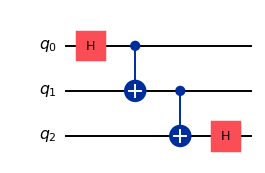

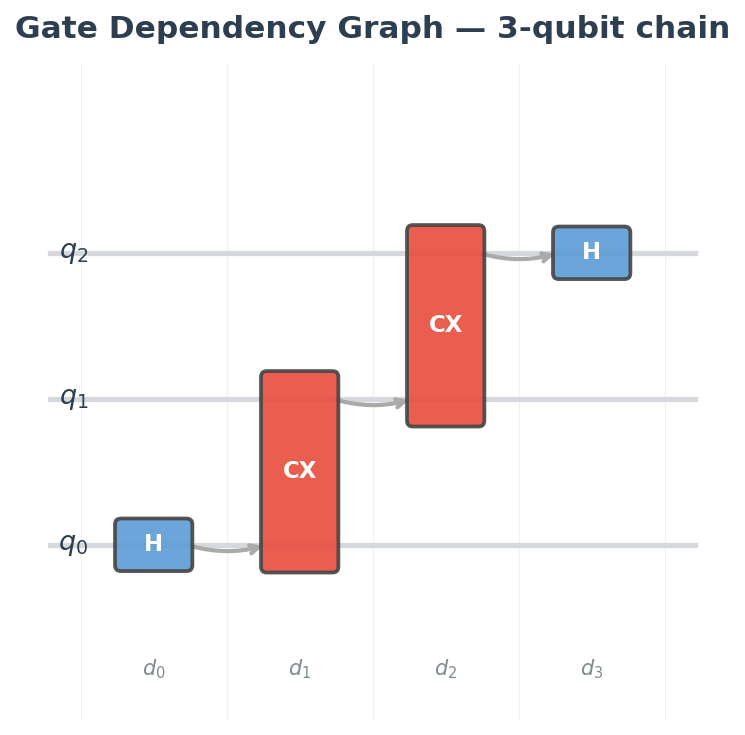

In [6]:
# ============================================================
# 示例 1: 3 量子比特 — 简单依赖链
# ============================================================
qc1 = QuantumCircuit(3)
qc1.h(0)
qc1.cx(0, 1)
qc1.cx(1, 2)
qc1.h(2)

gates1 = build_gate_dag(qc1)
print('Circuit 1:')
display(qc1.draw('mpl', scale=0.7).figure)
plt.show()

fig1, _ = draw_gate_dag(gates1, qc1.num_qubits,
                         title='Gate Dependency Graph — 3-qubit chain')
plt.show()

Circuit 2:


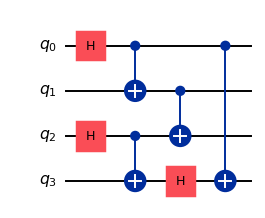

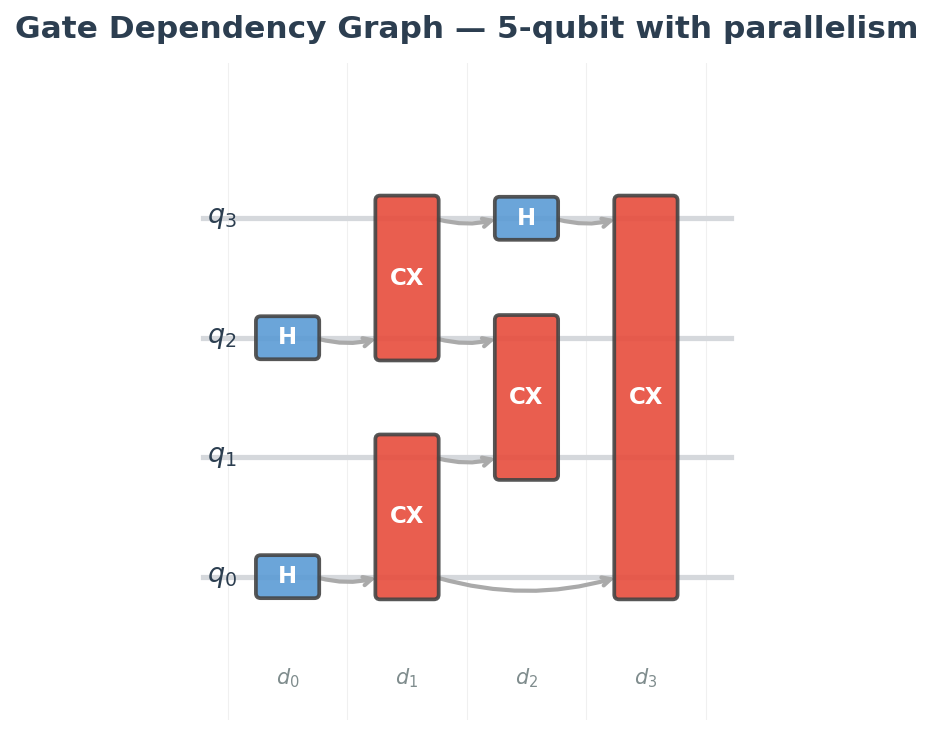

In [8]:
# ============================================================
# 示例 2: 4 量子比特 — 含并行门
# ============================================================
qc2 = QuantumCircuit(4)
qc2.h(0)
qc2.h(2)
qc2.cx(0, 1)
qc2.cx(2, 3)
qc2.cx(1, 2)
qc2.h(3)
qc2.cx(0, 3)

gates2 = build_gate_dag(qc2)
print('Circuit 2:')
display(qc2.draw('mpl', scale=0.7).figure)
plt.show()

fig2, _ = draw_gate_dag(gates2, qc2.num_qubits,
                         title='Gate Dependency Graph — 5-qubit with parallelism')
plt.show()

## 图结构说明

- **节点**：每个量子门（H, CX, SX 等）为一个节点
- **边**：同一逻辑比特上，前驱门 → 后继门（有向依赖边）
- **颜色**：
  - 🔵 蓝色 — 单比特门（H, X, Y, Z, S, T, SX, Rz）
  - 🔴 红色 — 双比特门（CX, CZ, SWAP, ECR）
- **布局**：水平方向 = DAG 深度（`d₀`, `d₁`, …），垂直方向 = 逻辑比特（`q₀`, `q₁`, …）

此图即二分异构图中的**逻辑线路图**（Logical Circuit Graph），与物理拓扑图（Physical Topology Graph）通过 `maps_to` 跨图映射边连接。